# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [2]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/andrerochadeoliveira/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminho da base construída no notebook 00
DATA_PATH = PROJECT_PATH / "data" / "processed" / "dataset_base.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("\nDiretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Repositório já disponível nesta sessão.

Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [3]:
# Gera a base analítica necessária para o EDA
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/00_preparacao_dados.ipynb" \
    --output "/tmp/00_preparacao_dados_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/00_preparacao_dados.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] Writing 85352 bytes to /tmp/00_preparacao_dados_executado.ipynb


In [5]:
# ============================================================
# VERIFICAÇÃO DA BASE GERADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)

Arquivo existe: True
Tamanho do arquivo: 2.60 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [6]:
# ============================================================
# 2. CARREGAMENTO DA BASE ANALÍTICA
# ============================================================

# Verifica se a base produzida pelo notebook 00 está disponível
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "O arquivo dataset_base.csv não foi encontrado. "
        "Execute primeiro o notebook 00_preparacao_dados.ipynb "
        "para gerar a base analítica."
    )

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (21694, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [ ]:
# ============================================================
# 3. VISÃO GERAL DA BASE
# ============================================================

print("Número de registros:", df.shape[0])
print("Número de variáveis:", df.shape[1])
print("Número de clientes:", df["ID"].nunique())

print("\nTipos das variáveis:")
print(df.dtypes.value_counts())

print("\nValores ausentes:")
print(df.isna().sum().sort_values(ascending=False).head())

percentual_ausente = (
    df["OCCUPATION_TYPE"].isna().mean() * 100
)

print(
    f"\nPercentual ausente em OCCUPATION_TYPE: "
    f"{percentual_ausente:.2f}%"
)

Número de registros: 21694
Número de variáveis: 19
Número de clientes: 21694

Tipos das variáveis:
int64      9
object     8
float64    2
Name: count, dtype: int64

Valores ausentes:
OCCUPATION_TYPE    6693
CODE_GENDER           0
ID                    0
FLAG_OWN_CAR          0
FLAG_OWN_REALTY       0
dtype: int64

Percentual ausente em OCCUPATION_TYPE: 30.85%


### Interpretação

A base analítica contém **21.694 registros e 21.694 clientes distintos**, indicando que cada linha representa um único cliente. O conjunto possui **19 variáveis**, sendo 11 numéricas (`int64` ou `float64`) e 8 categóricas (`object`).

Em relação à completude dos dados, a única variável com valores ausentes é `OCCUPATION_TYPE`, com **6.693 registros sem informação**, correspondentes a **30,85% da base**. Por representar uma parcela relevante das observações, esses registros não serão simplesmente excluídos nesta etapa. A estratégia de tratamento será avaliada posteriormente no pré-processamento.

In [ ]:
# ============================================================
# 4. IDENTIFICAÇÃO DOS TIPOS DE VARIÁVEIS
# ============================================================

variaveis_numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variaveis_categoricas = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variáveis armazenadas como numéricas:")
print(variaveis_numericas)

print("\nVariáveis armazenadas como categóricas:")
print(variaveis_categoricas)

Variáveis armazenadas como numéricas:
['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'target']

Variáveis armazenadas como categóricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [ ]:
# ============================================================
# 5. QUANTIDADE DE VALORES ÚNICOS POR VARIÁVEL
# ============================================================

valores_unicos = (
    df.nunique()
    .sort_values()
)

print(valores_unicos)

FLAG_MOBIL                 1
CODE_GENDER                2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_PHONE                 2
FLAG_WORK_PHONE            2
FLAG_EMAIL                 2
target                     2
NAME_FAMILY_STATUS         5
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_HOUSING_TYPE          6
CNT_CHILDREN               8
CNT_FAM_MEMBERS            9
OCCUPATION_TYPE           18
AMT_INCOME_TOTAL         246
DAYS_EMPLOYED           3326
DAYS_BIRTH              6275
ID                     21694
dtype: int64


### Classificação das variáveis

A análise da cardinalidade mostra que o tipo de armazenamento das variáveis não corresponde necessariamente à sua natureza estatística.

A variável `ID` funciona exclusivamente como identificador do cliente e não deve ser utilizada como variável explicativa na modelagem. O `target` e as variáveis `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE` e `FLAG_EMAIL` são binárias, embora estejam armazenadas como números inteiros.

Entre as variáveis binárias, `FLAG_MOBIL` apresenta apenas um valor em toda a base, não possuindo variabilidade entre os clientes. Por esse motivo, não apresenta poder discriminatório e deverá ser descartada no pré-processamento.

As demais variáveis numéricas representam características quantitativas ou discretas dos clientes, enquanto as variáveis armazenadas como `object` representam características categóricas. A variável `OCCUPATION_TYPE`, por exemplo, apresenta múltiplas categorias e valores ausentes, que serão tratados posteriormente.

Essa classificação será considerada nas etapas seguintes para definir as estratégias de análise, tratamento e preparação das variáveis para a modelagem.

In [ ]:
# ============================================================
# 6. AGRUPAMENTO DAS VARIÁVEIS PARA O EDA
# ============================================================

IDENTIFICADOR = "ID"

variaveis_quantitativas = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

variaveis_binarias = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "FLAG_MOBIL",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]

variaveis_categoricas = [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

print("Quantitativas:", len(variaveis_quantitativas))
print("Binárias:", len(variaveis_binarias))
print("Categóricas:", len(variaveis_categoricas))
print("Target:", TARGET)
print("Identificador:", IDENTIFICADOR)

Quantitativas: 5
Binárias: 7
Categóricas: 5
Target: target
Identificador: ID


In [ ]:
# ============================================================
# INVESTIGAÇÃO DE POSSÍVEIS DUPLICIDADES DE PERFIL
# ============================================================

# O ID é excluído porque queremos identificar registros
# com perfis cadastrais idênticos, mas IDs diferentes.
#
# O target também é excluído, pois faz parte da análise
# posterior e não deve ser utilizado para definir o perfil.
#
# AGE_YEARS, quando existir, também não deve ser considerada,
# pois é uma transformação de DAYS_BIRTH.

colunas_perfil = [
    coluna
    for coluna in df.columns
    if coluna not in ["ID", "target", "AGE_YEARS"]
]

# Agrupa clientes pelo conjunto completo de características
# cadastrais, incluindo os valores ausentes.
grupos_perfil = (
    df
    .groupby(
        colunas_perfil,
        dropna=False,
        sort=False
    )["ID"]
    .agg(list)
    .reset_index(name="IDs")
)

# Quantidade de IDs diferentes em cada perfil
grupos_perfil["qtd_ids"] = (
    grupos_perfil["IDs"].apply(len)
)

# Mantém somente perfis compartilhados por mais de um ID
grupos_gemeos = grupos_perfil[
    grupos_perfil["qtd_ids"] > 1
].copy()

print("=" * 60)
print("POSSÍVEIS DUPLICIDADES DE PERFIL")
print("=" * 60)

print(
    f"Perfis compartilhados por múltiplos IDs: "
    f"{len(grupos_gemeos):,}"
)

print(
    f"Clientes pertencentes a esses perfis: "
    f"{grupos_gemeos['qtd_ids'].sum():,}"
)

POSSÍVEIS DUPLICIDADES DE PERFIL
Perfis compartilhados por múltiplos IDs: 4,818
Clientes pertencentes a esses perfis: 18,353


In [ ]:
# ============================================================
# VERIFICAÇÃO DE TARGET ENTRE POSSÍVEIS DUPLICIDADES
# ============================================================

# Dicionário ID -> target
target_por_id = (
    df
    .set_index("ID")[TARGET]
    .to_dict()
)

# Identifica quais targets aparecem dentro de cada perfil
grupos_gemeos["targets"] = grupos_gemeos["IDs"].apply(
    lambda ids: sorted(
        {target_por_id[id_cliente] for id_cliente in ids}
    )
)

# Quantidade de classes de target presentes no grupo
grupos_gemeos["qtd_targets"] = (
    grupos_gemeos["targets"].apply(len)
)

# Perfis em que IDs diferentes apresentam targets diferentes
grupos_target_diferente = grupos_gemeos[
    grupos_gemeos["qtd_targets"] > 1
].copy()

print("=" * 60)
print("IMPACTO SOBRE A TARGET")
print("=" * 60)

print(
    f"Perfis com target igual entre os IDs: "
    f"{(grupos_gemeos['qtd_targets'] == 1).sum():,}"
)

print(
    f"Perfis com targets diferentes: "
    f"{len(grupos_target_diferente):,}"
)

print(
    f"IDs pertencentes a perfis com targets diferentes: "
    f"{grupos_target_diferente['qtd_ids'].sum():,}"
)

IMPACTO SOBRE A TARGET
Perfis com target igual entre os IDs: 4,535
Perfis com targets diferentes: 283
IDs pertencentes a perfis com targets diferentes: 1,265


In [ ]:
# ============================================================
# EXEMPLOS DE PERFIS COM TARGET DIFERENTE
# ============================================================

# IDs pertencentes aos primeiros perfis com target diferente
ids_exemplo = (
    grupos_target_diferente
    .iloc[0]["IDs"]
)

df_exemplo_gemeos = (
    df[
        df["ID"].isin(ids_exemplo)
    ]
    .sort_values("ID")
)

df_exemplo_gemeos

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
35,5008891,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
36,5008893,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
37,5008894,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
38,5008895,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
39,5008912,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
40,5008914,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
41,5008916,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
42,5008918,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
43,5008919,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0
44,5008920,F,N,Y,0,297000.0,Commercial associate,Secondary / secondary special,Single / not married,Rented apartment,-15519,-3234,1,0,0,0,Laborers,1.0,0


### Interpretação

A investigação de possíveis duplicidades de perfil identificou registros com **IDs diferentes, mas com o mesmo conjunto de características cadastrais**. Esses casos foram tratados nesta etapa como possíveis duplicidades de perfil, e não como duplicidades confirmadas, pois a igualdade das características disponíveis não é suficiente para comprovar que os registros correspondem à mesma pessoa.

Na população final de modelagem, foram identificados **4.818 perfis compartilhados por mais de um ID**, envolvendo **18.353 clientes**. Esse resultado indica que a base possui elevada ocorrência de perfis cadastrais idênticos associados a identificadores distintos.

A análise do `target` revelou um ponto de atenção adicional: **283 desses perfis apresentam IDs diferentes associados a classes distintas da variável-alvo**, envolvendo **1.265 clientes**. Nesses casos, clientes com características cadastrais idênticas apresentam diferentes classificações de risco segundo a regra de construção da target.

Esse resultado é relevante para as etapas posteriores de modelagem, pois pode indicar a existência de registros potencialmente correspondentes ao mesmo cliente com históricos de crédito distintos. Entretanto, como não é possível confirmar a identidade dos indivíduos apenas pelas variáveis disponíveis, esses casos não serão considerados duplicidades confirmadas nesta etapa.

A identificação desses perfis será utilizada posteriormente para definir uma estratégia adequada de tratamento e, principalmente, para evitar que possíveis registros correspondentes ao mesmo perfil sejam distribuídos de forma inadequada entre as amostras de treinamento e teste.

In [ ]:
# ============================================================
# RESUMO DAS POSSÍVEIS DUPLICIDADES DE PERFIL
# ============================================================

resumo_gemeos = pd.DataFrame({
    "Indicador": [
        "Perfis compartilhados por múltiplos IDs",
        "Clientes nesses perfis",
        "Perfis com targets diferentes",
        "IDs em perfis com targets diferentes"
    ],
    "Quantidade": [
        len(grupos_gemeos),
        grupos_gemeos["qtd_ids"].sum(),
        len(grupos_target_diferente),
        grupos_target_diferente["qtd_ids"].sum()
    ]
})

resumo_gemeos

,Indicador,Quantidade
0,Perfis compartilhados por múltiplos IDs,4818
1,Clientes nesses perfis,18353
2,Perfis com targets diferentes,283
3,IDs em perfis com targets diferentes,1265


## 2 — Análise das variáveis quantitativas

Nesta etapa são analisadas as distribuições e estatísticas descritivas das variáveis quantitativas. O objetivo é identificar características relevantes, possíveis assimetrias, valores extremos e situações que necessitem de investigação antes do pré-processamento.

In [ ]:
# ============================================================
# 7. ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS QUANTITATIVAS
# ============================================================

estatisticas_quantitativas = (
    df[variaveis_quantitativas]
    .describe()
    .T
)

estatisticas_quantitativas

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,21694.0,0.418042,0.745112,0.0,0.00,0.0,1.00,19.0
AMT_INCOME_TOTAL,21694.0,188782.610215,103176.617165,27000.0,121500.00,162000.0,225000.00,1575000.0
DAYS_BIRTH,21694.0,-16063.809302,4149.135399,-25152.0,-19481.25,-15687.5,-12615.00,-7757.0
DAYS_EMPLOYED,21694.0,58301.958929,136863.473264,-15713.0,-3232.00,-1600.0,-421.25,365243.0
CNT_FAM_MEMBERS,21694.0,2.190099,0.910407,1.0,2.00,2.0,3.00,20.0


### Interpretação

As estatísticas descritivas mostram comportamentos distintos entre as variáveis quantitativas. `CNT_CHILDREN` apresenta forte concentração em valores baixos: a mediana é 0 e 75% dos clientes possuem até 1 filho. `CNT_FAM_MEMBERS` também apresenta concentração em famílias pequenas, com mediana de 2 e terceiro quartil igual a 3.

`AMT_INCOME_TOTAL` apresenta assimetria à direita, com média de aproximadamente R$ 188,8 mil superior à mediana de R$ 162 mil. O valor máximo de R$ 1,575 milhão também evidencia a presença de clientes com rendas bastante superiores ao centro da distribuição, aspecto que será investigado nas etapas seguintes.

`DAYS_BIRTH` possui valores negativos em razão da forma como a idade é representada na base. A mediana de aproximadamente -15,7 mil dias corresponde a cerca de 43 anos, enquanto os valores observados indicam uma população adulta.

`DAYS_EMPLOYED` merece atenção especial. Embora a mediana seja de -1.600 dias, a média é elevada e o máximo chega a 365.243 dias. Esse comportamento decorre da existência de um código especial na base que não representa efetivamente um tempo de emprego e deverá ser tratado posteriormente no pré-processamento.

De modo geral, as variáveis quantitativas apresentam diferentes escalas, assimetrias e possíveis valores extremos. Esses aspectos serão considerados nas etapas posteriores de preparação dos dados e modelagem.

In [ ]:
# ============================================================
# 8. INVESTIGAÇÃO DE DAYS_EMPLOYED
# ============================================================

print("Maiores valores de DAYS_EMPLOYED:")
print(
    df["DAYS_EMPLOYED"]
    .value_counts()
    .sort_index(ascending=False)
    .head(10)
)

print("\nQuantidade de valores positivos:")
print((df["DAYS_EMPLOYED"] > 0).sum())

print("\nPercentual de valores positivos:")
print(
    round(
        (df["DAYS_EMPLOYED"] > 0).mean() * 100,
        2
    )
)

Maiores valores de DAYS_EMPLOYED:
DAYS_EMPLOYED
 365243    3597
-17           2
-43           1
-65           2
-66           1
-70           2
-71           1
-73          11
-78           1
-88           1
Name: count, dtype: int64

Quantidade de valores positivos:
3597

Percentual de valores positivos:
16.58


### Análise de `DAYS_EMPLOYED`

A variável `DAYS_EMPLOYED` apresenta uma característica relevante. Embora a maior parte dos registros possua valores negativos, compatíveis com a representação do tempo de emprego em dias anteriores à data de referência, foram identificados **3.597 registros com o valor positivo `365243`**, correspondentes a **16,58% da base**.

Todos os valores positivos encontrados estão concentrados nesse mesmo valor. Considerando sua magnitude, `365243` não representa um tempo de emprego plausível e deve ser interpretado como um valor especial presente na base.

A presença desse código afeta diretamente estatísticas como a média de `DAYS_EMPLOYED`, tornando-a pouco representativa da distribuição real da variável. O tratamento desses registros será definido posteriormente na etapa de pré-processamento.

In [ ]:
# ============================================================
# 9. INVESTIGAÇÃO DA COMPOSIÇÃO FAMILIAR
# ============================================================

print("Distribuição de CNT_CHILDREN:")
print(
    df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição de CNT_FAM_MEMBERS:")
print(
    df["CNT_FAM_MEMBERS"]
    .value_counts()
    .sort_index()
)

Distribuição de CNT_CHILDREN:
CNT_CHILDREN
0     15215
1      4286
2      1898
3       247
4        35
5         9
14        3
19        1
Name: count, dtype: int64

Distribuição de CNT_FAM_MEMBERS:
CNT_FAM_MEMBERS
1.0      4141
2.0     11744
3.0      3733
4.0      1791
5.0       239
6.0        34
7.0         8
15.0        3
20.0        1
Name: count, dtype: int64


### Análise da composição familiar

A distribuição de `CNT_CHILDREN` mostra forte concentração de clientes sem filhos: **15.215 clientes (70,14%)** não possuem filhos, enquanto **19,76%** possuem um filho e **8,75%** possuem dois. Os casos com três ou mais filhos representam apenas **1,36%** da população.

Em relação a `CNT_FAM_MEMBERS`, observa-se concentração ainda maior em famílias pequenas. **54,13% dos clientes possuem dois membros na família**, enquanto 19,09% possuem um membro, 17,21% possuem três e 8,26% possuem quatro. Os casos com cinco ou mais membros representam apenas **1,31%** da população.

Em conjunto, as duas variáveis indicam que a população analisada é predominantemente composta por clientes pertencentes a estruturas familiares de pequeno porte. A baixa frequência de valores elevados também deverá ser considerada na análise de possíveis valores extremos e na preparação das variáveis para a modelagem.

In [ ]:
# ============================================================
# 10. VERIFICAÇÃO DOS CASOS EXTREMOS DE COMPOSIÇÃO FAMILIAR
# ============================================================

casos_extremos_familia = df.loc[
    (df["CNT_CHILDREN"] >= 7) |
    (df["CNT_FAM_MEMBERS"] >= 9),
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].sort_values(
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"],
    ascending=False
)

casos_extremos_familia

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
14944,5105054,19,20.0,Single / not married
8361,5061207,14,15.0,Separated
8362,5061210,14,15.0,Separated
8363,5061211,14,15.0,Separated


### Análise dos casos extremos de composição familiar

A inspeção dos casos extremos identificou poucos registros com valores elevados de `CNT_CHILDREN` ou `CNT_FAM_MEMBERS`. Na população analisada, foram encontrados quatro casos que atendem aos critérios definidos para investigação.

Os maiores valores observados apresentam coerência entre as duas variáveis: o cliente com 19 filhos possui 20 membros na família, enquanto os três clientes com 14 filhos possuem 15 membros familiares. Essa consistência sugere que os valores elevados estão relacionados entre si e não indicam, por si só, erro evidente de preenchimento.

Embora sejam observações raras e possam influenciar algumas medidas estatísticas, não há evidência suficiente nesta etapa para classificá-las como erros. Dessa forma, os registros serão mantidos, e seu eventual tratamento será avaliado posteriormente no pré-processamento.

In [ ]:
# ============================================================
# 11. INVESTIGAÇÃO DA RENDA
# ============================================================

print("Quantis de AMT_INCOME_TOTAL:")

print(
    df["AMT_INCOME_TOTAL"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
)

print("\n10 maiores valores de renda:")

print(
    df["AMT_INCOME_TOTAL"]
    .nlargest(10)
)

Quantis de AMT_INCOME_TOTAL:
0.50     162000.0
0.75     225000.0
0.90     315000.0
0.95     360000.0
0.99     562500.0
1.00    1575000.0
Name: AMT_INCOME_TOTAL, dtype: float64

10 maiores valores de renda:
20097    1575000.0
20098    1575000.0
20099    1575000.0
20100    1575000.0
20101    1575000.0
420      1350000.0
421      1350000.0
422      1350000.0
2957     1125000.0
12633    1125000.0
Name: AMT_INCOME_TOTAL, dtype: float64


### Análise da renda

A variável `AMT_INCOME_TOTAL` apresenta assimetria à direita, com concentração dos valores em faixas inferiores e uma cauda formada por clientes com rendas mais elevadas. A média da renda, de aproximadamente **R$ 188,8 mil**, é superior à mediana de **R$ 162 mil**, reforçando essa assimetria.

A distribuição apresenta mediana de R$ 162.000 e terceiro quartil de R$ 225.000. Até o percentil 90, os valores chegam a R$ 315.000, enquanto o percentil 95 alcança R$ 360.000 e o percentil 99 chega a R$ 562.500. O valor máximo observado é de **R$ 1.575.000**, substancialmente superior aos principais quantis da distribuição.

Os maiores valores aparecem repetidos em vários registros, incluindo cinco clientes com renda de R$ 1.575.000, três com R$ 1.350.000 e dois com R$ 1.125.000. Portanto, não se trata de observações isoladas. Nesta etapa, não há evidência suficiente para classificá-los como erros. Esses valores serão mantidos durante a análise exploratória, e seu eventual tratamento e impacto sobre o pré-processamento e a modelagem serão avaliados posteriormente.

In [ ]:
# ============================================================
# 12. CONVERSÃO DE DAYS_BIRTH PARA IDADE
# ============================================================

# Cria uma variável apenas para facilitar a interpretação no EDA.
# A variável original é preservada.
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25)

print(df["AGE_YEARS"].describe().round(2))

count    21694.00
mean        43.98
std         11.36
min         21.24
25%         34.54
50%         42.95
75%         53.34
max         68.86
Name: AGE_YEARS, dtype: float64


### Análise da idade

A variável `DAYS_BIRTH` foi convertida para idade aproximada em anos apenas para facilitar sua interpretação durante a análise exploratória, preservando-se a variável original.

A população analisada possui idade entre aproximadamente **21 e 69 anos**, com **média de 43,98 anos** e **mediana de 42,95 anos**. Metade dos clientes possui idade entre aproximadamente **34,54 e 53,34 anos**, indicando uma população adulta relativamente ampla em termos etários.

Os valores observados apresentam uma faixa etária plausível, não sendo identificadas, nesta análise inicial, idades incompatíveis com a população estudada.

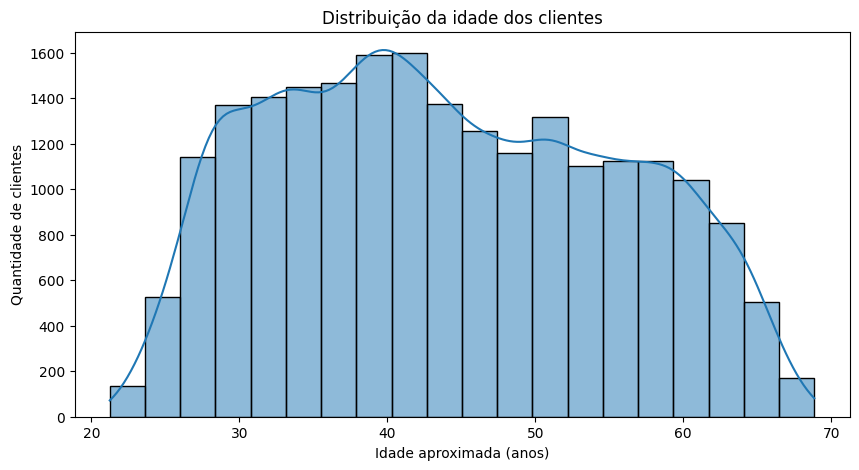

In [ ]:
# ============================================================
# 13. DISTRIBUIÇÃO DA IDADE
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AGE_YEARS",
    bins=20,
    kde=True
)

plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade aproximada (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

A distribuição das idades abrange aproximadamente **21 a 69 anos**, com maior concentração de clientes nas faixas etárias intermediárias e pico visual próximo dos 40 anos. Observa-se redução gradual da frequência nas idades mais elevadas, sem descontinuidades evidentes na distribuição.

A média de idade é de **43,98 anos**, enquanto a mediana é de **42,95 anos**. A proximidade entre essas medidas indica que não há forte assimetria na distribuição da idade.

De modo geral, a distribuição apresenta uma faixa etária plausível e não evidencia, nesta etapa, valores incompatíveis ou inconsistências aparentes na variável.

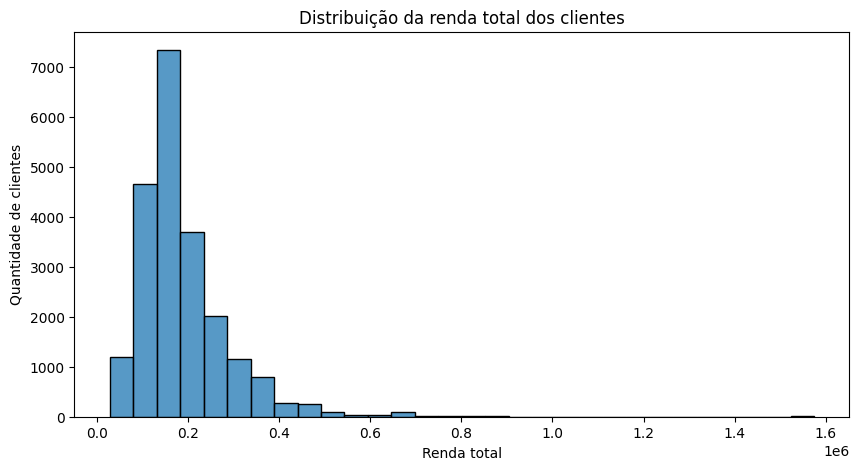

In [ ]:
# ============================================================
# 14. DISTRIBUIÇÃO DA RENDA TOTAL
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total dos clientes")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

A distribuição da `AMT_INCOME_TOTAL` apresenta forte **assimetria à direita**. A maior parte dos clientes está concentrada nas faixas inferiores e intermediárias de renda, enquanto uma parcela reduzida de observações com rendas elevadas forma uma cauda longa à direita.

Essa característica é consistente com as estatísticas descritivas observadas anteriormente: a mediana é de **R$ 162.000**, o percentil 95 é de **R$ 360.000** e o percentil 99 alcança **R$ 562.500**, enquanto o valor máximo chega a **R$ 1.575.000**.

A presença desses valores elevados amplia significativamente a escala do gráfico e dificulta a visualização detalhada da região onde se concentra a maior parte dos clientes. Por esse motivo, será utilizada também uma visualização complementar limitada ao percentil 99 da renda, sem excluir ou modificar os registros da base original.

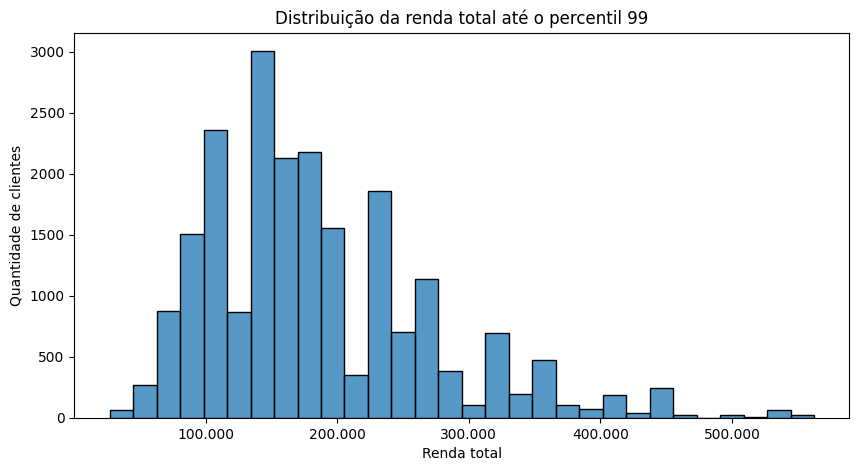

Percentil 99 da renda: 562,500.00


In [ ]:
# ============================================================
# 15. DISTRIBUIÇÃO DA RENDA ATÉ O PERCENTIL 99
# ============================================================

limite_renda_99 = df["AMT_INCOME_TOTAL"].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["AMT_INCOME_TOTAL"] <= limite_renda_99],
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total até o percentil 99")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.show()

print(f"Percentil 99 da renda: {limite_renda_99:,.2f}")

### Interpretação da distribuição até o percentil 99

A visualização limitada ao percentil 99 permite observar com maior detalhe a região em que se concentra a maior parte dos clientes. O **percentil 99 da renda é de R$ 562.500**, de modo que o gráfico apresenta os valores até esse limite exclusivamente para fins de visualização.

Mesmo desconsiderando visualmente o 1% de maiores valores, a distribuição permanece assimétrica à direita, com maior concentração nas faixas inferiores e intermediárias de renda e redução da frequência à medida que os valores aumentam.

Também são observadas concentrações em determinados níveis de renda, indicando a ocorrência recorrente de alguns valores no conjunto de dados. A limitação ao percentil 99 foi aplicada exclusivamente para fins de visualização e **não representa exclusão ou alteração das observações da base original**.

In [ ]:
# ============================================================
# 16. TEMPO DE EMPREGO EM ANOS
# ============================================================

# Considera somente os valores negativos de DAYS_EMPLOYED.
# O código especial 365243 não entra neste cálculo.
tempo_emprego_valido = df.loc[
    df["DAYS_EMPLOYED"] < 0,
    "DAYS_EMPLOYED"
]

tempo_emprego_anos = -tempo_emprego_valido / 365.25

print("Registros com tempo de emprego válido:", len(tempo_emprego_anos))
print("\nEstatísticas do tempo de emprego (anos):")
print(tempo_emprego_anos.describe().round(2))

Registros com tempo de emprego válido: 18097

Estatísticas do tempo de emprego (anos):
count    18097.00
mean         7.41
std          6.57
min          0.05
25%          2.71
50%          5.63
75%          9.84
max         43.02
Name: DAYS_EMPLOYED, dtype: float64


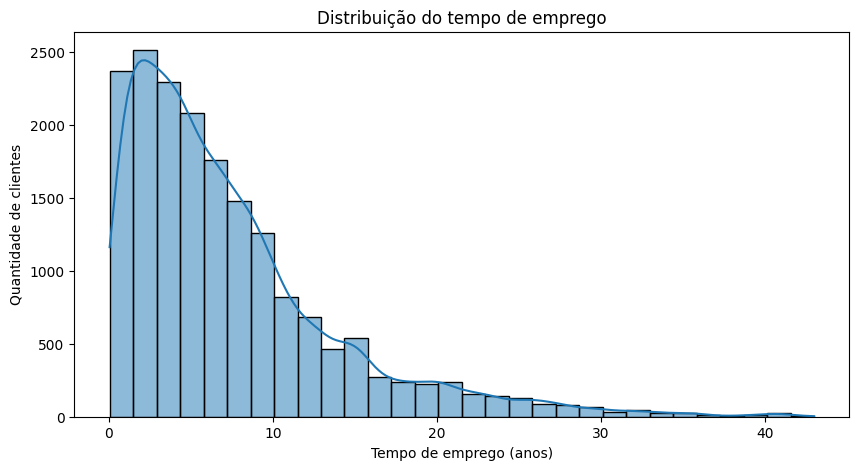

In [ ]:
# ============================================================
# 17. DISTRIBUIÇÃO DO TEMPO DE EMPREGO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    x=tempo_emprego_anos,
    bins=30,
    kde=True
)

plt.title("Distribuição do tempo de emprego")
plt.xlabel("Tempo de emprego (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

Considerando apenas os **18.097 registros com valores interpretáveis de `DAYS_EMPLOYED`**, observa-se uma distribuição assimétrica à direita. A maior concentração de clientes ocorre nos menores tempos de emprego, enquanto a frequência diminui progressivamente à medida que o tempo de emprego aumenta.

A mediana do tempo de emprego é de aproximadamente **5,63 anos**, enquanto a média é de **7,41 anos**. A média superior à mediana é compatível com a presença de uma cauda à direita, observada também no histograma. O maior tempo de emprego entre os registros válidos é de aproximadamente **43 anos**.

Os **3.597 registros originalmente codificados como `365243`**, correspondentes a **16,58% da base**, não foram incluídos nesta visualização, pois esse valor não representa um tempo de emprego plausível. Esses registros permanecem preservados na base original e seu tratamento será definido posteriormente na etapa de pré-processamento.

In [ ]:
# ============================================================
# 18. RELAÇÃO ENTRE FILHOS E TAMANHO DA FAMÍLIA
# ============================================================

correlacao_familia = df[
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
].corr()

print(correlacao_familia)

                 CNT_CHILDREN  CNT_FAM_MEMBERS
CNT_CHILDREN         1.000000         0.889603
CNT_FAM_MEMBERS      0.889603         1.000000


### Relação entre número de filhos e tamanho da família

As variáveis `CNT_CHILDREN` e `CNT_FAM_MEMBERS` apresentam correlação de Pearson de aproximadamente **0,89**, indicando uma forte associação linear positiva. Esse comportamento é coerente com a natureza das variáveis, uma vez que o número de filhos contribui diretamente para o tamanho do grupo familiar.

A elevada correlação também indica que as duas variáveis carregam informações parcialmente redundantes sobre a composição familiar. Essa característica deverá ser considerada posteriormente na preparação dos dados e na modelagem.

A inspeção realizada anteriormente também mostrou consistência nos registros com valores mais elevados. Apesar da existência de poucos casos extremos, não foram identificados indícios suficientes para considerá-los erros nesta etapa.

## 3 — Análise das variáveis categóricas e binárias

Nesta etapa são analisadas as distribuições das características categóricas e binárias dos clientes. O objetivo é identificar categorias predominantes, categorias pouco frequentes, variáveis sem variabilidade e possíveis aspectos relevantes para o pré-processamento e a modelagem.

In [ ]:
# ============================================================
# 19. DISTRIBUIÇÃO DAS VARIÁVEIS BINÁRIAS
# ============================================================

for coluna in variaveis_binarias:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


CODE_GENDER
-----------
             quantidade  percentual
CODE_GENDER                        
F                 14425       66.49
M                  7269       33.51

FLAG_OWN_CAR
------------
              quantidade  percentual
FLAG_OWN_CAR                        
N                  13284       61.23
Y                   8410       38.77

FLAG_OWN_REALTY
---------------
                 quantidade  percentual
FLAG_OWN_REALTY                        
Y                     14217       65.53
N                      7477       34.47

FLAG_MOBIL
----------
            quantidade  percentual
FLAG_MOBIL                        
1                21694       100.0

FLAG_WORK_PHONE
---------------
                 quantidade  percentual
FLAG_WORK_PHONE                        
0                     16717       77.06
1                      4977       22.94

FLAG_PHONE
----------
            quantidade  percentual
FLAG_PHONE                        
0                15227       70.19
1             

### Interpretação das variáveis binárias

As variáveis binárias apresentam diferentes níveis de concentração entre suas categorias. A base possui maior proporção de clientes do sexo feminino (**66,49%**), sem automóvel próprio (**61,23%**) e com imóvel próprio (**65,53%**).

Em relação às informações de contato, **22,94%** dos clientes possuem telefone de trabalho registrado, **29,81%** possuem telefone e apenas **9,34%** possuem e-mail registrado. Portanto, as informações de contato apresentam níveis relativamente baixos de disponibilidade, especialmente no caso do e-mail.

A variável `FLAG_MOBIL` apresenta valor igual a 1 para **todos os 21.694 clientes**, não possuindo variabilidade na população analisada. Dessa forma, essa variável não apresenta capacidade de diferenciação entre os clientes e deverá ser descartada na etapa de pré-processamento.

De modo geral, as variáveis binárias apresentam diferentes níveis de concentração, sendo importante considerar essa distribuição nas análises posteriores, especialmente para verificar se categorias muito predominantes apresentam capacidade de discriminação em relação à variável-alvo.

In [ ]:
# ============================================================
# 20. DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

for coluna in variaveis_categoricas:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


NAME_INCOME_TYPE
----------------
                      quantidade  percentual
NAME_INCOME_TYPE                            
Working                    11160       51.44
Commercial associate        5179       23.87
Pensioner                   3614       16.66
State servant               1732        7.98
Student                        9        0.04

NAME_EDUCATION_TYPE
-------------------
                               quantidade  percentual
NAME_EDUCATION_TYPE                                  
Secondary / secondary special       14659       67.57
Higher education                     5947       27.41
Incomplete higher                     842        3.88
Lower secondary                       225        1.04
Academic degree                        21        0.10

NAME_FAMILY_STATUS
------------------
                      quantidade  percentual
NAME_FAMILY_STATUS                          
Married                    15074       69.48
Single / not married        2815       12.98
Civil marria

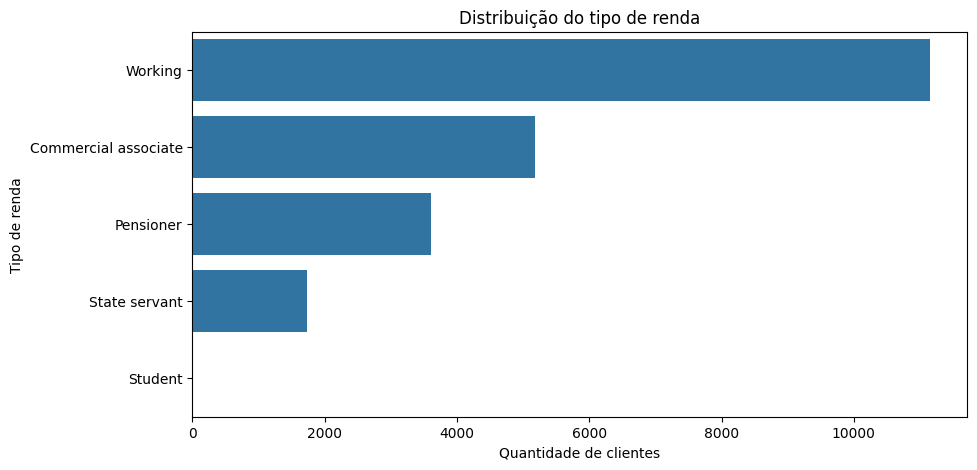

In [ ]:
# ============================================================
# 21. DISTRIBUIÇÃO DO TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_INCOME_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Distribuição do tipo de renda")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de renda")

plt.show()

### Interpretação

A distribuição do tipo de renda é concentrada principalmente na categoria `Working`, que representa **51,44%** dos clientes, seguida por `Commercial associate`, com **23,87%**, e `Pensioner`, com **16,66%**. A categoria `State servant` corresponde a **7,98%** da base, enquanto `Student` representa apenas **0,04%**, com 9 registros.

A distribuição mostra predominância de clientes classificados como `Working` e `Commercial associate`, que juntos representam aproximadamente **75,31% da população**. Também se observa baixa frequência em algumas categorias, especialmente `Student`.

As categorias pouco frequentes serão avaliadas posteriormente no pré-processamento, considerando sua representatividade e a necessidade de uma codificação adequada para a modelagem.

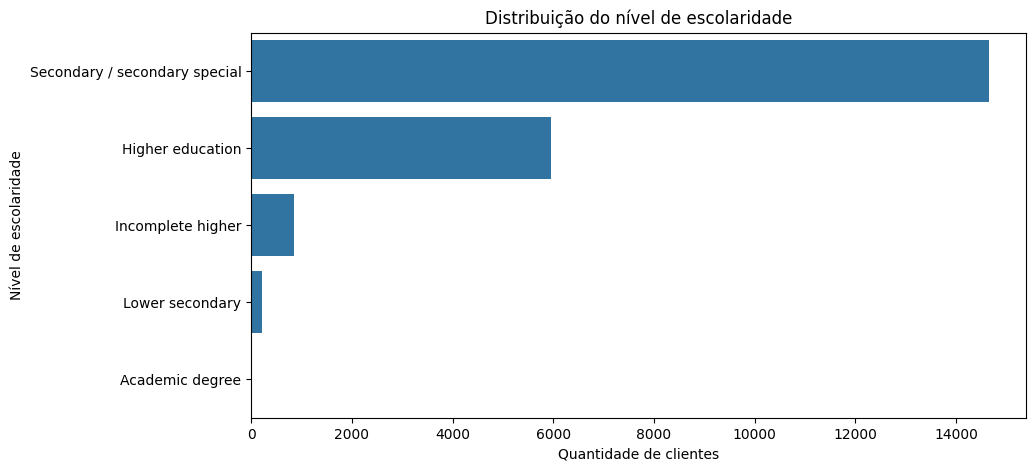

In [ ]:
# ============================================================
# 22. DISTRIBUIÇÃO DO NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_EDUCATION_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Distribuição do nível de escolaridade")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Nível de escolaridade")

plt.show()

### Interpretação

A distribuição do nível de escolaridade apresenta forte concentração em duas categorias. `Secondary / secondary special` representa **67,57%** dos clientes, enquanto `Higher education` corresponde a **27,41%**. As demais categorias apresentam participação bastante reduzida: `Incomplete higher` representa **3,88%**, `Lower secondary` **1,04%** e `Academic degree` apenas **0,10%** da base.

Essa concentração indica baixa frequência em algumas categorias, especialmente `Academic degree` e `Lower secondary`. Esse comportamento deverá ser considerado posteriormente na etapa de pré-processamento, principalmente na definição da estratégia de codificação das variáveis categóricas.

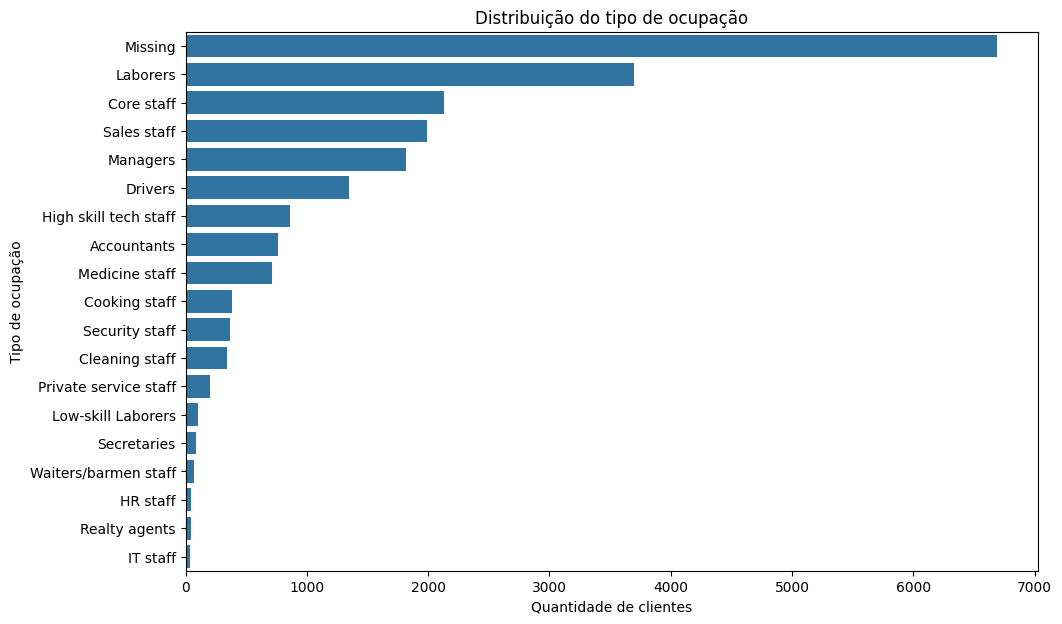

In [ ]:
# ============================================================
# 23. DISTRIBUIÇÃO DO TIPO DE OCUPAÇÃO
# ============================================================

ocupacao_plot = df["OCCUPATION_TYPE"].fillna("Missing")

ordem_ocupacao = (
    ocupacao_plot
    .value_counts()
    .index
)

plt.figure(figsize=(11, 7))

sns.countplot(
    y=ocupacao_plot,
    order=ordem_ocupacao
)

plt.title("Distribuição do tipo de ocupação")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de ocupação")

plt.show()

### Interpretação

A distribuição de `OCCUPATION_TYPE` apresenta elevada concentração de valores ausentes. A categoria `Missing` corresponde a **30,85% da população**, representando 6.693 clientes, o que caracteriza uma parcela relevante da base sem informação sobre o tipo de ocupação.

Entre as ocupações informadas, `Laborers` é a categoria mais frequente, com **17,02%** dos clientes, seguida por `Core staff` (**9,81%**), `Sales staff` (**9,19%**) e `Managers` (**8,38%**). As demais ocupações apresentam participações inferiores a 7%.

Além da elevada proporção de valores ausentes, observa-se uma distribuição bastante fragmentada entre as categorias de ocupação. A variável deverá, portanto, receber atenção específica na etapa de pré-processamento, tanto em relação ao tratamento dos valores ausentes quanto à representação das categorias de menor frequência.

## 4 — Análise da variável-alvo

A variável `target` representa o evento definido na etapa de preparação dos dados. Nesta etapa será analisada sua distribuição, com atenção à proporção entre as classes e ao possível desbalanceamento da base.

In [ ]:
# ============================================================
# 24. DISTRIBUIÇÃO DO TARGET
# ============================================================

contagem_target = df[TARGET].value_counts().sort_index()

percentual_target = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumo_target = pd.DataFrame({
    "quantidade": contagem_target,
    "percentual": percentual_target
})

resumo_target

,quantidade,percentual
target,,
0,21185,97.65
1,509,2.35


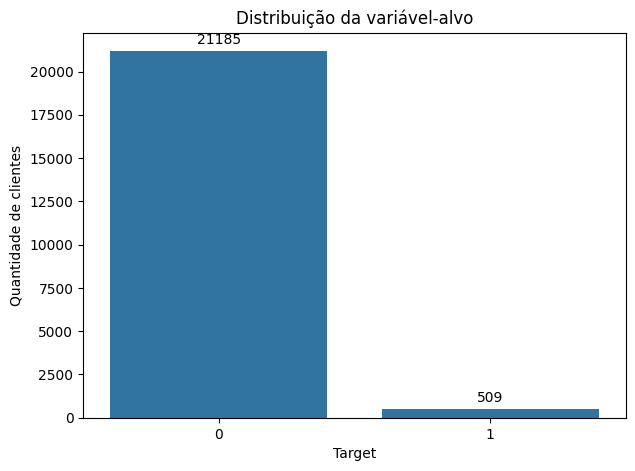

In [ ]:
# ============================================================
# 25. VISUALIZAÇÃO DA DISTRIBUIÇÃO DO TARGET
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    order=[0, 1]
)

plt.title("Distribuição da variável-alvo")
plt.xlabel("Target")
plt.ylabel("Quantidade de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.show()

### Interpretação

A variável-alvo apresenta forte desbalanceamento entre as classes. A classe `0` reúne **21.185 clientes (97,65%)**, enquanto a classe `1`, correspondente aos clientes classificados como evento de risco segundo a regra definida na etapa de preparação dos dados, reúne **509 clientes (2,35%)**.

A baixa proporção da classe `1` é uma característica relevante da base, pois significa que os eventos de risco representam uma parcela reduzida da população analisada. Esse desbalanceamento deverá ser considerado nas etapas posteriores de divisão da amostra, treinamento e avaliação dos modelos, especialmente na escolha das métricas de desempenho.

A distribuição original do `target` será mantida nesta etapa exploratória. Eventuais estratégias para lidar com o desbalanceamento serão avaliadas posteriormente no processo de modelagem.

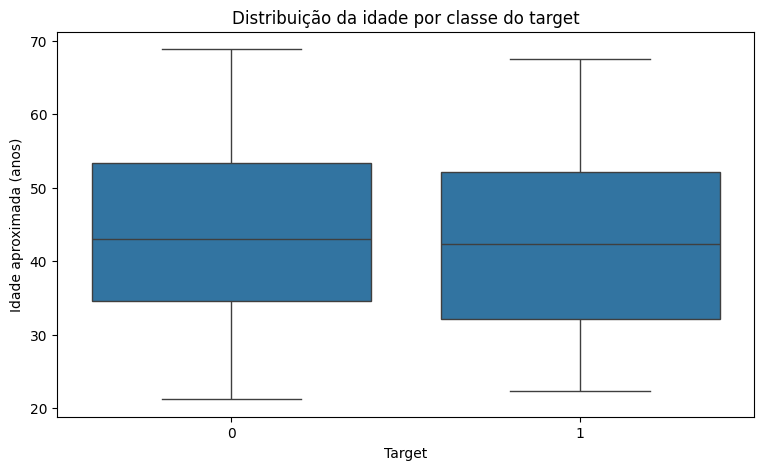

In [ ]:
# ============================================================
# 26. IDADE POR CLASSE DO TARGET
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="AGE_YEARS"
)

plt.title("Distribuição da idade por classe do target")
plt.xlabel("Target")
plt.ylabel("Idade aproximada (anos)")

plt.show()

### Interpretação

A distribuição da idade apresenta pequenas diferenças entre as classes do `target`, com considerável sobreposição entre os grupos. Visualmente, a mediana da idade é ligeiramente menor entre os clientes classificados como `target = 1` em comparação com `target = 0`.

Os intervalos interquartis e as amplitudes observadas são semelhantes entre as duas classes, indicando que a idade, isoladamente, não apresenta uma separação evidente entre clientes com e sem evento.

A visualização permite identificar uma diferença descritiva entre os grupos, mas não é suficiente, por si só, para estabelecer uma relação causal entre idade e ocorrência do evento.

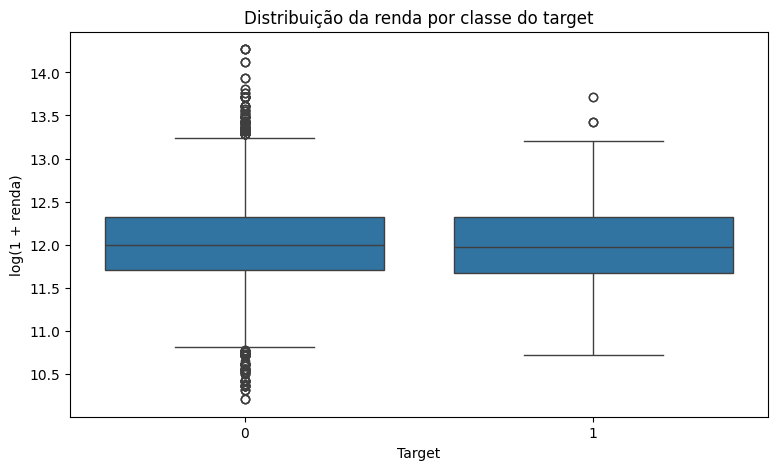

In [ ]:
# ============================================================
# 27. RENDA POR CLASSE DO TARGET
# ============================================================

df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="LOG_INCOME"
)

plt.title("Distribuição da renda por classe do target")
plt.xlabel("Target")
plt.ylabel("log(1 + renda)")

plt.show()

### Interpretação

As distribuições da renda apresentam comportamento semelhante entre as duas classes do target, com medianas muito próximas. Visualmente, a mediana da renda no grupo `target = 1` é ligeiramente inferior à observada no grupo `target = 0`, mas a diferença é pequena.

Também são observados valores extremos em ambas as classes, principalmente na região superior da distribuição. A utilização de `log(1 + renda)` nesta visualização reduz a influência dos valores extremos sobre a escala do gráfico, permitindo uma comparação mais adequada entre os grupos.

A análise gráfica, isoladamente, não indica uma separação acentuada entre as classes com base apenas na renda. A variável original `AMT_INCOME_TOTAL` será preservada para as etapas posteriores.

In [ ]:
# Remove variável criada exclusivamente para visualização
df.drop(columns=["LOG_INCOME"], inplace=True)

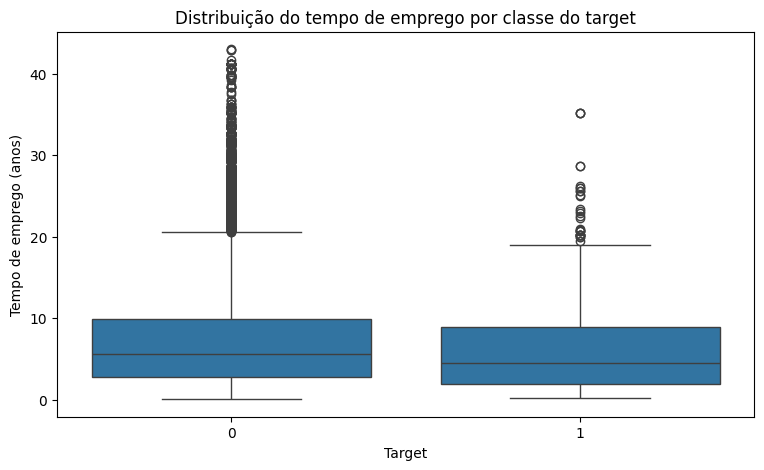

In [ ]:
# ============================================================
# 28. TEMPO DE EMPREGO POR CLASSE DO TARGET
# ============================================================

df_emprego = df.loc[
    df["DAYS_EMPLOYED"] < 0
].copy()

df_emprego["EMPLOYMENT_YEARS"] = (
    -df_emprego["DAYS_EMPLOYED"] / 365.25
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_emprego,
    x=TARGET,
    y="EMPLOYMENT_YEARS"
)

plt.title("Distribuição do tempo de emprego por classe do target")
plt.xlabel("Target")
plt.ylabel("Tempo de emprego (anos)")

plt.show()

### Interpretação

Considerando somente os registros com valores interpretáveis de `DAYS_EMPLOYED`, observa-se uma diferença descritiva entre as classes do target. A mediana do tempo de emprego é ligeiramente menor entre os clientes classificados como `target = 1` em comparação com `target = 0`.

Os intervalos interquartis apresentam considerável sobreposição entre os grupos, embora o `target = 0` apresente uma mediana um pouco superior. Ambas as classes possuem uma cauda superior extensa, com registros de longo tempo de emprego e diversos valores extremos.

A visualização não evidencia uma separação acentuada entre `target = 0` e `target = 1` com base exclusivamente no tempo de emprego. Os registros originalmente codificados como `365243` não foram considerados nesta comparação, pois representam um código especial cujo tratamento será definido posteriormente no pré-processamento.

In [ ]:
# ============================================================
# 29. TAXA DO TARGET POR TIPO DE RENDA
# ============================================================

taxa_target_renda = (
    df.groupby("NAME_INCOME_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_renda["percentual_target_1"] = (
    taxa_target_renda["mean"] * 100
).round(2)

taxa_target_renda

,count,sum,mean,percentual_target_1
NAME_INCOME_TYPE,,,,
Commercial associate,5179,129,0.024908,2.49
Pensioner,3614,89,0.024626,2.46
Working,11160,255,0.022849,2.28
State servant,1732,36,0.020785,2.08
Student,9,0,0.000000,0.00


### Interpretação

As taxas observadas de `target = 1` apresentam pouca variação entre os diferentes tipos de renda, variando de 0,00% a 2,49%.

A maior proporção foi observada entre os clientes classificados como `Commercial associate` (2,49%), seguida por `Pensioner` (2,46%), `Working` (2,28%) e `State servant` (2,08%).

A categoria `Student` apresentou taxa de 0,00%, pois não houve nenhum caso de `target = 1` entre os 9 clientes dessa categoria. Entretanto, devido ao número muito reduzido de observações, essa taxa deve ser interpretada com cautela.

De forma geral, as diferenças entre as categorias são pequenas, sugerindo que o tipo de renda, isoladamente, não apresenta forte diferenciação entre as classes do target nesta análise descritiva. Essa análise não permite estabelecer relação causal entre o tipo de renda e a ocorrência do evento.

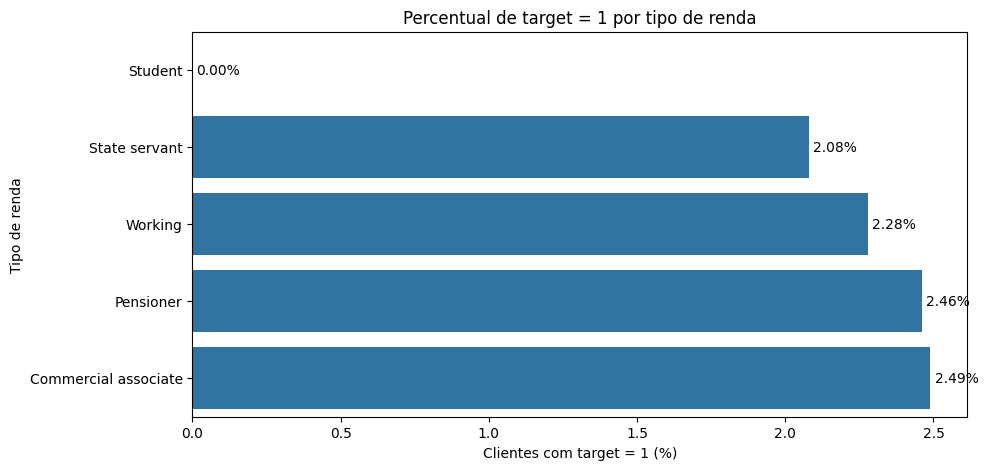

In [ ]:
# ============================================================
# 30. TAXA DE TARGET = 1 POR TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = taxa_target_renda["percentual_target_1"].sort_values().index

ax = sns.barplot(
    data=taxa_target_renda.reset_index(),
    x="percentual_target_1",
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de renda")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de renda")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

As taxas de ocorrência de `target = 1` apresentam pouca variação entre os diferentes tipos de renda, variando de 0,00% a 2,49%.

A maior taxa foi observada entre os clientes classificados como `Commercial associate` (2,49%), seguida por `Pensioner` (2,46%), `Working` (2,28%) e `State servant` (2,08%).

A categoria `Student` apresentou taxa de 0,00%, pois nenhum dos 9 clientes dessa categoria apresentou `target = 1`. Devido ao número muito reduzido de observações, essa categoria deve ser interpretada com cautela.

De forma geral, as diferenças observadas entre os tipos de renda são pequenas. A análise é descritiva e, isoladamente, não permite estabelecer relação causal entre o tipo de renda e a ocorrência do evento.

In [ ]:
# ============================================================
# 31. TAXA DO TARGET POR NÍVEL DE ESCOLARIDADE
# ============================================================

taxa_target_escolaridade = (
    df.groupby("NAME_EDUCATION_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_escolaridade["percentual_target_1"] = (
    taxa_target_escolaridade["mean"] * 100
).round(2)

taxa_target_escolaridade

,count,sum,mean,percentual_target_1
NAME_EDUCATION_TYPE,,,,
Incomplete higher,842,33,0.039192,3.92
Secondary / secondary special,14659,345,0.023535,2.35
Higher education,5947,127,0.021355,2.14
Lower secondary,225,4,0.017778,1.78
Academic degree,21,0,0.000000,0.00


### Interpretação

As taxas de ocorrência de `target = 1` apresentam diferenças entre os níveis de escolaridade, variando de 0,00% a 3,92%.

A maior taxa foi observada entre os clientes classificados como `Incomplete higher` (3,92%), seguida por `Secondary / secondary special` (2,35%) e `Higher education` (2,14%). A categoria `Lower secondary` apresentou taxa de 1,78%.

A categoria `Academic degree` apresentou taxa de 0,00%, pois nenhum dos 21 clientes dessa categoria apresentou `target = 1`. Devido ao pequeno número de observações, essa categoria deve ser interpretada com cautela.

De forma geral, observa-se alguma diferença descritiva entre as categorias, principalmente pela taxa mais elevada de `Incomplete higher`. Entretanto, as diferenças observadas não permitem estabelecer causalidade entre nível de escolaridade e ocorrência do evento. Categorias com poucos registros também podem apresentar taxas menos estáveis.

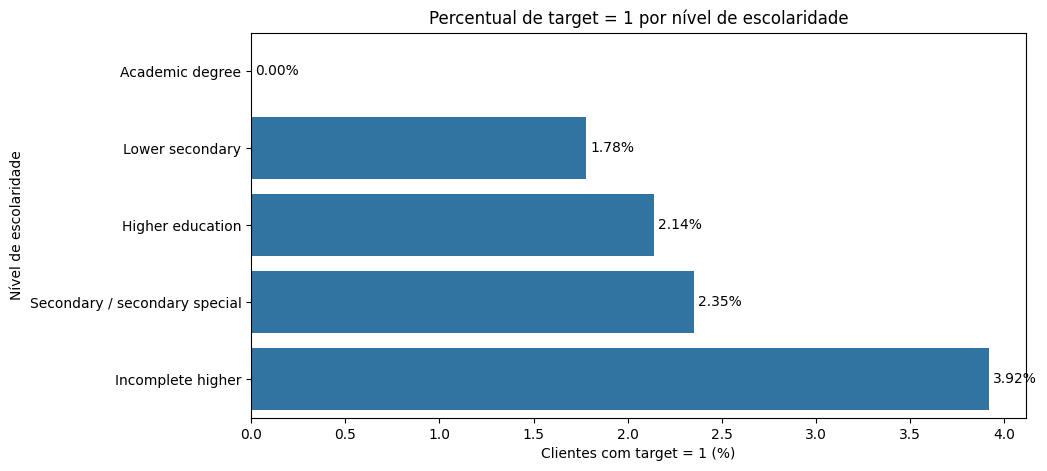

In [ ]:
# ============================================================
# 32. TAXA DE TARGET = 1 POR NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    taxa_target_escolaridade["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_escolaridade.reset_index(),
    x="percentual_target_1",
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por nível de escolaridade")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Nível de escolaridade")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

A categoria `Incomplete higher` apresenta a maior taxa observada de `target = 1` (3,92%), seguida por `Secondary / secondary special` (2,35%), `Higher education` (2,14%) e `Lower secondary` (1,78%).

A categoria `Academic degree` apresenta taxa de 0,00%, pois nenhum dos 21 clientes desse grupo apresentou `target = 1`. Entretanto, o pequeno número de observações reduz a estabilidade dessa estimativa. Portanto, as taxas devem ser analisadas conjuntamente com o tamanho de cada grupo.

De forma geral, observa-se alguma diferença entre as categorias, mas a análise é descritiva e, isoladamente, não permite estabelecer relação causal entre nível de escolaridade e ocorrência do evento.

In [ ]:
# ============================================================
# 33. TAXA DO TARGET POR ESTADO CIVIL
# ============================================================

taxa_target_estado_civil = (
    df.groupby("NAME_FAMILY_STATUS")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_estado_civil["percentual_target_1"] = (
    taxa_target_estado_civil["mean"] * 100
).round(2)

taxa_target_estado_civil

,count,sum,mean,percentual_target_1
NAME_FAMILY_STATUS,,,,
Single / not married,2815,88,0.031261,3.13
Separated,1271,30,0.023603,2.36
Married,15074,337,0.022356,2.24
Widow,868,19,0.021889,2.19
Civil marriage,1666,35,0.021008,2.10


### Interpretação

As taxas de ocorrência de `target = 1` apresentam diferenças relativamente pequenas entre as categorias de estado civil, variando de 2,10% a 3,13%.

A maior taxa foi observada entre os clientes classificados como `Single / not married` (3,13%), seguida por `Separated` (2,36%), `Married` (2,24%), `Widow` (2,19%) e `Civil marriage` (2,10%).

A categoria `Married` concentra a maior quantidade de clientes da base, com 15.074 registros, e apresentou taxa de 2,24%. Portanto, embora `Single / not married` apresente a maior taxa observada, a diferença em relação às demais categorias é relativamente pequena.

De forma geral, as diferenças observadas são descritivas e, isoladamente, não permitem estabelecer relação causal entre estado civil e ocorrência do evento.

In [ ]:
# ============================================================
# 34. TAXA DO TARGET POR TIPO DE OCUPAÇÃO
# ============================================================

df["OCCUPATION_TYPE_EDA"] = df["OCCUPATION_TYPE"].fillna("Missing")

taxa_target_ocupacao = (
    df.groupby("OCCUPATION_TYPE_EDA")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_ocupacao["percentual_target_1"] = (
    taxa_target_ocupacao["mean"] * 100
).round(2)

taxa_target_ocupacao

,count,sum,mean,percentual_target_1
OCCUPATION_TYPE_EDA,,,,
IT staff,40,3,0.075000,7.50
HR staff,48,3,0.062500,6.25
Waiters/barmen staff,71,4,0.056338,5.63
Realty agents,41,2,0.048780,4.88
Low-skill Laborers,104,5,0.048077,4.81
Security staff,367,13,0.035422,3.54
Cleaning staff,339,11,0.032448,3.24
Medicine staff,714,22,0.030812,3.08
Managers,1817,55,0.030270,3.03


### Interpretação

As taxas de ocorrência de `target = 1` apresentam variação entre as categorias de ocupação, de 1,18% a 7,50%.

As maiores taxas foram observadas entre `IT staff` (7,50%), `HR staff` (6,25%) e `Waiters/barmen staff` (5,63%). Entretanto, essas categorias possuem poucos registros, com 40, 48 e 71 clientes, respectivamente, o que recomenda cautela na interpretação dessas taxas.

Também se destacam `Realty agents` (4,88%) e `Low-skill Laborers` (4,81%), que igualmente apresentam tamanhos amostrais reduzidos. Portanto, taxas elevadas em categorias pequenas não devem ser interpretadas isoladamente como evidência de maior ocorrência do evento.

Entre as categorias com maior quantidade de observações, `Managers` apresentou taxa de 3,03%, `Laborers` 2,14%, `Drivers` 2,08% e `Sales staff` 2,06%. A categoria `Missing`, que possui 6.693 registros, apresentou taxa de 2,17%.

De forma geral, os resultados indicam diferenças descritivas entre as categorias de ocupação, mas a estabilidade dessas taxas depende também do número de observações de cada grupo. A análise, por si só, não permite estabelecer relação causal entre ocupação e ocorrência do evento.

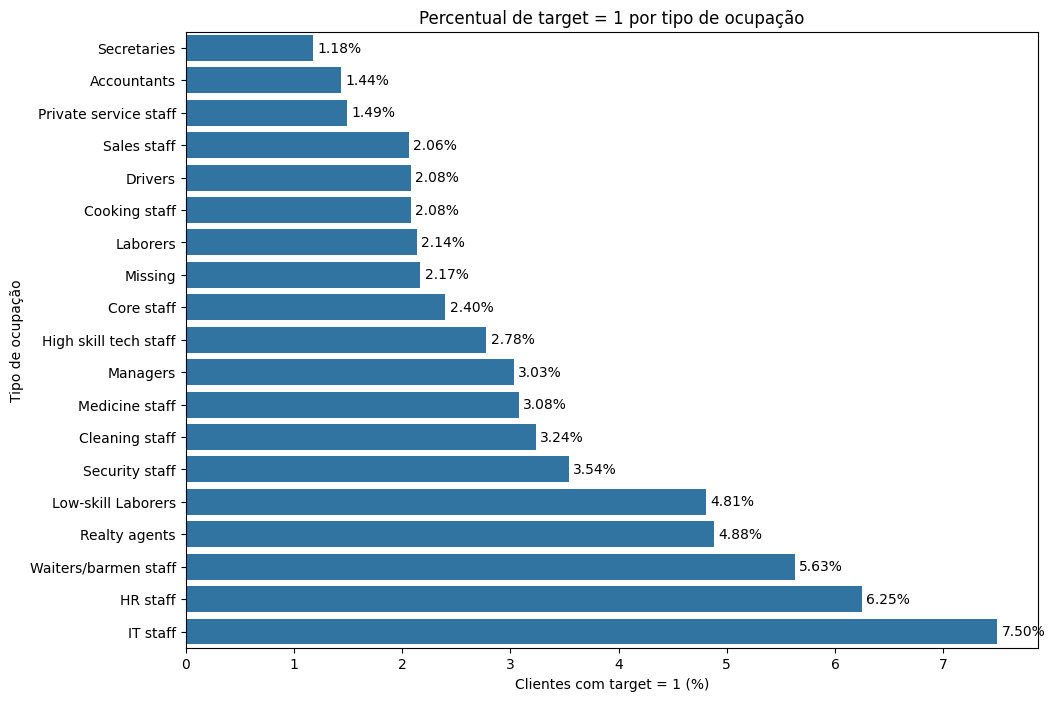

In [ ]:
# ============================================================
# 35. TAXA DE TARGET = 1 POR TIPO DE OCUPAÇÃO
# ============================================================

plt.figure(figsize=(11, 8))

ordem = (
    taxa_target_ocupacao["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_ocupacao.reset_index(),
    x="percentual_target_1",
    y="OCCUPATION_TYPE_EDA",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de ocupação")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de ocupação")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

A distribuição da taxa de `target = 1` apresenta diferenças entre os tipos de ocupação, variando de **1,18% a 7,50%**.

As maiores taxas foram observadas em `IT staff` (7,50%), `HR staff` (6,25%) e `Waiters/barmen staff` (5,63%). Entretanto, essas categorias possuem poucos registros, respectivamente **40, 48 e 71 clientes**, o que reduz a estabilidade dessas estimativas e recomenda cautela em sua interpretação.

Também se observam taxas relativamente elevadas em `Realty agents` (4,88%) e `Low-skill Laborers` (4,81%), que igualmente apresentam volumes reduzidos de observações. Portanto, uma taxa elevada em uma categoria pequena não deve ser interpretada isoladamente como evidência de maior probabilidade do evento.

Entre as categorias com maior representatividade na base, destacam-se `Managers` (3,03%), `Medicine staff` (3,08%), `Laborers` (2,14%), `Drivers` (2,08%) e `Sales staff` (2,06%). A categoria `Missing`, com **6.693 registros**, apresentou taxa de **2,17%**.

De forma geral, a variável `OCCUPATION_TYPE` apresenta diferenças descritivas na ocorrência de `target = 1`, mas essas diferenças devem ser analisadas conjuntamente com o tamanho das categorias. Esta análise é exploratória e não permite estabelecer relação causal entre ocupação e ocorrência do evento.

In [ ]:
# Remove variável criada exclusivamente para o EDA
df.drop(columns=["OCCUPATION_TYPE_EDA"], inplace=True)

## 5 — Relações entre variáveis
Nesta etapa são analisadas as relações entre as principais variáveis quantitativas da base, com o objetivo de identificar associações relevantes e possíveis redundâncias entre as variáveis explicativas.

In [ ]:
# ============================================================
# 36. CORRELAÇÃO ENTRE VARIÁVEIS QUANTITATIVAS
# ============================================================

variaveis_correlacao = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS",
    TARGET
]

matriz_corr = df[variaveis_correlacao].corr()

matriz_corr.round(3)

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,target
CNT_CHILDREN,1.000,0.032,0.338,-0.221,0.890,0.003
AMT_INCOME_TOTAL,0.032,1.000,0.070,-0.171,0.024,0.005
DAYS_BIRTH,0.338,0.070,1.000,-0.608,0.303,0.017
DAYS_EMPLOYED,-0.221,-0.171,-0.608,1.000,-0.218,-0.001
CNT_FAM_MEMBERS,0.890,0.024,0.303,-0.218,1.000,-0.003
target,0.003,0.005,0.017,-0.001,-0.003,1.000


### Interpretação

A matriz de correlação evidencia uma forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,890), indicando possível redundância entre essas variáveis. Também foi observada uma correlação negativa relativamente forte entre `DAYS_BIRTH` e `DAYS_EMPLOYED` (-0,608), enquanto as demais associações entre as variáveis quantitativas são predominantemente baixas.

As correlações lineares individuais com a variável-alvo são muito baixas, variando de -0,003 a 0,017. Entretanto, esses valores não devem ser utilizados isoladamente para avaliar o potencial preditivo das variáveis, pois o `target` é binário e relações não lineares ou efeitos combinados entre variáveis podem não ser capturados pela correlação de Pearson.

A forte correlação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` deve ser considerada nas etapas posteriores de pré-processamento e modelagem, especialmente para avaliar possível redundância entre as variáveis explicativas.

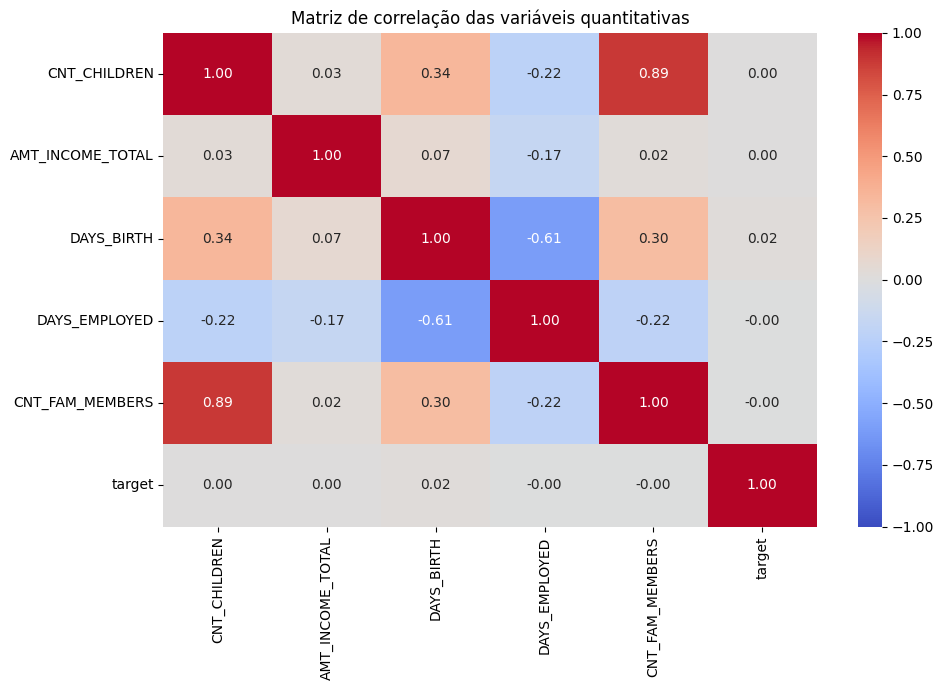

In [ ]:
# ============================================================
# 37. HEATMAP DA MATRIZ DE CORRELAÇÃO
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlação das variáveis quantitativas")
plt.tight_layout()
plt.show()

### Interpretação

O heatmap confirma a forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,89), indicando possível redundância entre essas variáveis. Também se observa uma associação negativa de magnitude moderada a forte entre `DAYS_BIRTH` e `DAYS_EMPLOYED` (-0,61).

As demais correlações entre as variáveis quantitativas são relativamente baixas. As correlações individuais com o `target` também apresentam baixa magnitude, variando aproximadamente entre -0,003 e 0,017. Entretanto, esses valores não devem ser utilizados isoladamente para avaliar o potencial preditivo das variáveis, pois o `target` é binário e relações não lineares ou efeitos combinados entre variáveis podem não ser capturados pela correlação de Pearson.

A forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` deverá ser considerada nas etapas posteriores de pré-processamento e modelagem, especialmente na avaliação de possível redundância entre as variáveis explicativas.

## 6. Síntese da EDA

A análise exploratória foi realizada sobre a base final de modelagem, composta por 21.694 clientes. Essa população resulta das etapas de preparação e integração das bases cadastral e de histórico de crédito realizadas anteriormente. Na base final não foram identificados registros duplicados por cliente e não há valores ausentes na variável-alvo. O `target` apresenta forte desbalanceamento, com 21.185 clientes (97,65%) classificados como `0` e 509 (2,35%) classificados como `1`. Essa característica deverá ser considerada nas etapas posteriores de divisão da amostra, treinamento e avaliação dos modelos, especialmente na escolha das métricas de desempenho.

A análise das variáveis quantitativas evidencia diferentes características de distribuição. A idade apresenta considerável sobreposição entre as classes do `target`, sem separação visual acentuada entre os grupos. A renda total apresenta assimetria à direita e presença de valores extremos, característica que deve ser considerada nas etapas posteriores de pré-processamento. O tempo de emprego também apresenta distribuição assimétrica e uma quantidade relevante de observações com valores extremos.

Na variável `DAYS_EMPLOYED`, foi identificada uma codificação específica (`365243`) que não representa um tempo de emprego interpretável. Esse valor corresponde a 3.597 registros e foi excluído das visualizações destinadas à análise do tempo de emprego. Considerando os registros com valores interpretáveis, foram analisados 18.097 clientes, com mediana de aproximadamente 5,63 anos de emprego. O tratamento específico dessa codificação deverá ser realizado posteriormente no pré-processamento.

Entre as variáveis categóricas, observa-se predominância de clientes do sexo feminino (66,49%), clientes com imóvel próprio (65,53%) e clientes sem veículo próprio (61,23%). A maior parte dos clientes possui ensino secundário ou equivalente (67,57%), é casada (69,48%) e reside em casa ou apartamento (89,33%). Quanto ao tipo de renda, predominam clientes classificados como `Working` (51,44%) e `Commercial associate` (23,87%).

Um dos principais pontos de atenção identificados foi `OCCUPATION_TYPE`, que apresenta 6.693 registros ausentes, correspondentes a 30,85% da base. A variável também apresenta diversas categorias com baixa frequência. As taxas de `target = 1` variam entre as ocupações, mas as categorias com poucos registros apresentam maior instabilidade nas estimativas. Dessa forma, o tratamento dos valores ausentes e das categorias de baixa frequência deverá considerar conjuntamente a representatividade das categorias e seu impacto sobre a modelagem.

Na análise bivariada com o `target`, as diferenças observadas entre as categorias de tipo de renda foram relativamente pequenas. As taxas de `target = 1` variaram de 0,00% a 2,49%, desconsiderando a categoria `Student`, que possui apenas 9 observações. Entre as categorias com maior representatividade, `Commercial associate` apresentou 2,49%, `Pensioner` 2,46%, `Working` 2,28% e `State servant` 2,08%.

Na variável de escolaridade, as taxas de `target = 1` também apresentaram diferenças entre as categorias. `Incomplete higher` apresentou a maior taxa entre as categorias com maior representatividade, com 3,92%, enquanto `Secondary / secondary special` apresentou 2,35% e `Higher education` 2,14%. Categorias com poucos registros, como `Academic degree`, devem ser interpretadas com cautela devido ao reduzido tamanho amostral.

Em relação ao estado civil, as taxas de `target = 1` variaram de 2,10% a 3,13%. A maior taxa foi observada entre clientes classificados como `Single / not married` (3,13%), enquanto `Married`, categoria predominante na base, apresentou 2,24%. As diferenças observadas são descritivas e não permitem estabelecer relação causal entre estado civil e ocorrência do evento.

A análise da ocupação apresentou maior amplitude nas taxas de `target = 1`, variando de 1,18% a 7,50%. As maiores taxas foram observadas em categorias de menor frequência, como `IT staff`, `HR staff` e `Waiters/barmen staff`. Entre as categorias mais numerosas, as taxas foram mais moderadas. Esse comportamento reforça a necessidade de considerar o tamanho amostral conjuntamente com a taxa observada, evitando interpretações baseadas exclusivamente em percentuais de categorias pouco representadas.

A comparação das distribuições de idade, renda e tempo de emprego entre as classes do `target` não revelou, visualmente, uma separação acentuada entre os grupos. Apesar de pequenas diferenças nas medianas e na dispersão, existe considerável sobreposição entre as distribuições. Portanto, essas variáveis não devem ser avaliadas isoladamente para determinar seu potencial preditivo.

Por fim, a análise de correlação identificou forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,89), indicando possível redundância entre essas variáveis. Também foi observada correlação negativa de magnitude moderada a forte entre `DAYS_BIRTH` e `DAYS_EMPLOYED` (-0,61). As demais correlações entre as variáveis quantitativas foram predominantemente baixas. As correlações lineares individuais com o `target` também foram baixas, mas esse resultado não deve ser interpretado como ausência de capacidade preditiva, pois o `target` é binário e relações não lineares ou efeitos combinados entre variáveis podem não ser capturados pela correlação de Pearson.

De forma geral, a EDA indica três pontos principais de atenção para as próximas etapas: **o forte desbalanceamento do `target`, o tratamento de valores ausentes e códigos especiais — especialmente em `OCCUPATION_TYPE` e `DAYS_EMPLOYED` — e a possível redundância entre algumas variáveis quantitativas**. Esses achados deverão orientar o pré-processamento, a seleção e transformação das variáveis e a construção dos modelos preditivos nas etapas seguintes.